In [1]:
import pandas as pd
import numpy as np

In [2]:
import tensorflow as tf
from tensorflow import keras

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [6]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 19.3 MB/s eta 0:00:00


In [7]:
import optuna

In [8]:
file_path = "/content/bengaluru_house_prices.csv"

df = pd.read_csv(file_path)

In [9]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [10]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 13320
Columns: 9


In [11]:
df.columns.tolist()

['area_type',
 'availability',
 'location',
 'size',
 'society',
 'total_sqft',
 'bath',
 'balcony',
 'price']

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [13]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [14]:
df.duplicated().sum()

np.int64(529)

In [15]:
df.nunique()

,0
area_type,4
availability,81
location,1305
size,31
society,2688
total_sqft,2117
bath,19
balcony,4
price,1994


In [16]:
df["price"].describe()

,price
count,13320.000000
mean,112.565627
std,148.971674
min,8.000000
25%,50.000000
50%,72.000000
75%,120.000000
max,3600.000000


In [17]:
print("area_type:", df["area_type"].nunique())
print("availability:", df["availability"].nunique())
print("location:", df["location"].nunique())
print("society:", df["society"].nunique())

area_type: 4
availability: 81
location: 1305
society: 2688


In [18]:
df["size"].value_counts().head(15)

,count
size,
2 BHK,5199
3 BHK,4310
4 Bedroom,826
4 BHK,591
3 Bedroom,547
1 BHK,538
2 Bedroom,329
5 Bedroom,297
6 Bedroom,191


In [19]:
df["total_sqft"].head(20)

,total_sqft
0,1056
1,2600
2,1440
3,1521
4,1200
5,1170
6,2732
7,3300
8,1310
9,1020


In [20]:
df = df.drop_duplicates().reset_index(drop=True)

print("New shape:", df.shape)

New shape: (12791, 9)


In [21]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5328
total_sqft,0
bath,73
balcony,605
price,0


In [22]:
df["bhk"] = df["size"].str.extract(r"(\d+)").astype(float)

In [23]:
df[["size", "bhk"]].head(10)

,size,bhk
0,2 BHK,2.0
1,4 Bedroom,4.0
2,3 BHK,3.0
3,3 BHK,3.0
4,2 BHK,2.0
5,2 BHK,2.0
6,4 BHK,4.0
7,4 BHK,4.0
8,3 BHK,3.0
9,6 Bedroom,6.0


In [24]:
df["bhk"].isnull().sum()

np.int64(16)

In [25]:
non_numeric_sqft = df[
    pd.to_numeric(df["total_sqft"], errors="coerce").isnull()
]

print("Non-numeric total_sqft:", len(non_numeric_sqft))

non_numeric_sqft[["total_sqft"]].head(20)

Non-numeric total_sqft: 246


,total_sqft
30,2100 - 2850
56,3010 - 3410
81,2957 - 3450
122,3067 - 8156
137,1042 - 1105
165,1145 - 1340
188,1015 - 1540
224,1520 - 1740
410,34.46Sq. Meter
549,1195 - 1440


In [26]:
def convert_sqft_to_num(value):
    try:
        value = str(value).strip()

        # Range: 2100 - 2850
        if "-" in value:
            parts = value.split("-")
            return (float(parts[0]) + float(parts[1])) / 2

        # Square Meter
        if "Sq. Meter" in value:
            number = float(value.replace("Sq. Meter", "").strip())
            return number * 10.7639

        # Perch
        if "Perch" in value:
            number = float(value.replace("Perch", "").strip())
            return number * 272.25

        # Normal numeric value
        return float(value)

    except:
        return np.nan

In [27]:
df["total_sqft_num"] = df["total_sqft"].apply(convert_sqft_to_num)

In [28]:
df[["total_sqft", "total_sqft_num"]].head(20)

,total_sqft,total_sqft_num
0,1056,1056.0
1,2600,2600.0
2,1440,1440.0
3,1521,1521.0
4,1200,1200.0
5,1170,1170.0
6,2732,2732.0
7,3300,3300.0
8,1310,1310.0
9,1020,1020.0


In [29]:
print("Missing total_sqft:", df["total_sqft_num"].isnull().sum())

Missing total_sqft: 28


In [30]:
df[df["total_sqft"].astype(str).str.contains("-", regex=False)][
    ["total_sqft", "total_sqft_num"]
].head(10)

,total_sqft,total_sqft_num
30,2100 - 2850,2475.0
56,3010 - 3410,3210.0
81,2957 - 3450,3203.5
122,3067 - 8156,5611.5
137,1042 - 1105,1073.5
165,1145 - 1340,1242.5
188,1015 - 1540,1277.5
224,1520 - 1740,1630.0
549,1195 - 1440,1317.5
579,1200 - 2400,1800.0


In [31]:
df[df["total_sqft_num"].isnull()][
    ["total_sqft", "location", "size", "price"]
]

,total_sqft,location,size,price
872,1100Sq. Yards,Singapura Village,2 BHK,45.0
1018,5.31Acres,Marathi Layout,1 Bedroom,110.0
1085,30Acres,Narasapura,2 Bedroom,29.5
1812,1574Sq. Yards,Sarjapur,3 Bedroom,76.0
2296,361.33Sq. Yards,Whitefield,4 BHK,270.0
2854,117Sq. Yards,Volagerekallahalli,2 BHK,38.0
3248,500Sq. Yards,Whitefield,4 Bedroom,378.0
4238,315Sq. Yards,Bannerghatta Road,4 BHK,260.0
5361,3Cents,Kannur,6 Bedroom,75.0
5441,188.89Sq. Yards,Frazer Town,3 BHK,180.0


In [32]:
df[["location", "size", "bhk", "total_sqft_num", "bath", "balcony", "society"]].isnull().sum()

,0
location,1
size,16
bhk,16
total_sqft_num,28
bath,73
balcony,605
society,5328


In [33]:
df = df.dropna(
    subset=["location", "bhk", "total_sqft_num"]
).reset_index(drop=True)

In [34]:
print("Shape after cleaning essential features:", df.shape)

Shape after cleaning essential features: (12746, 11)


In [35]:
df["bath"] = df["bath"].fillna(df["bath"].median())

In [36]:
df["balcony"] = df["balcony"].fillna(df["balcony"].median())

In [37]:
df["society"] = df["society"].fillna("Unknown")

In [38]:
print("Missing location:", df["location"].isnull().sum())

Missing location: 0


In [39]:
df.isnull().sum()

,0
area_type,0
availability,0
location,0
size,0
society,0
total_sqft,0
bath,0
balcony,0
price,0
bhk,0


In [40]:
df = df.drop(columns=["size", "total_sqft"])

In [41]:
df.columns.tolist()

['area_type',
 'availability',
 'location',
 'society',
 'bath',
 'balcony',
 'price',
 'bhk',
 'total_sqft_num']

In [42]:
df["area_type"].value_counts()

,count
area_type,
Super built-up Area,8314
Built-up Area,2389
Plot Area,1956
Carpet Area,87


In [43]:
df["availability"].value_counts().head(20)

,count
availability,
Ready To Move,10146
18-May,291
18-Dec,284
18-Apr,269
18-Aug,187
19-Dec,176
18-Jul,131
18-Mar,129
18-Jun,98


In [44]:
print("Number of locations:", df["location"].nunique())

Number of locations: 1298


In [45]:
print("Number of societies:", df["society"].nunique())

Number of societies: 2675


In [47]:
df["is_ready_to_move"] = (
    df["availability"] == "Ready To Move"
).astype(int)

In [48]:
df["is_ready_to_move"].value_counts()

,count
is_ready_to_move,
1,10146
0,2600


In [49]:
location_frequency = df["location"].value_counts(normalize=True)

df["location_frequency"] = df["location"].map(location_frequency)

In [50]:
df[["location", "location_frequency"]].head(10)

,location,location_frequency
0,Electronic City Phase II,0.010042
1,Chikka Tirupathi,0.001255
2,Uttarahalli,0.012318
3,Lingadheeranahalli,0.001804
4,Kothanur,0.005021
5,Whitefield,0.040797
6,Old Airport Road,0.002275
7,Rajaji Nagar,0.008395
8,Marathahalli,0.013259
9,Gandhi Bazar,0.000157


In [51]:
society_frequency = df["society"].value_counts(normalize=True)

df["society_frequency"] = df["society"].map(society_frequency)

In [52]:
df[["society", "society_frequency"]].head(10)

,society,society_frequency
0,Coomee,0.000392
1,Theanmp,0.000941
2,Unknown,0.416287
3,Soiewre,0.001726
4,Unknown,0.416287
5,DuenaTa,0.000078
6,Jaades,0.001177
7,Brway G,0.001648
8,Unknown,0.416287
9,Unknown,0.416287


In [53]:
df = pd.get_dummies(
    df,
    columns=["area_type"],
    drop_first=True,
    dtype=int
)

In [54]:
df.columns.tolist()

['availability',
 'location',
 'society',
 'bath',
 'balcony',
 'price',
 'bhk',
 'total_sqft_num',
 'is_ready_to_move',
 'location_frequency',
 'society_frequency',
 'area_type_Carpet  Area',
 'area_type_Plot  Area',
 'area_type_Super built-up  Area']

In [55]:
df = df.drop(
    columns=["availability", "location", "society"]
)

In [56]:
print("Shape:", df.shape)
display(df.head())

Shape: (12746, 11)


,bath,balcony,price,bhk,total_sqft_num,is_ready_to_move,location_frequency,society_frequency,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
0,2.0,1.0,39.07,2.0,1056.0,0,0.010042,0.000392,0,0,1
1,5.0,3.0,120.00,4.0,2600.0,1,0.001255,0.000941,0,1,0
2,2.0,3.0,62.00,3.0,1440.0,1,0.012318,0.416287,0,0,0
3,3.0,1.0,95.00,3.0,1521.0,1,0.001804,0.001726,0,0,1
4,2.0,1.0,51.00,2.0,1200.0,1,0.005021,0.416287,0,0,1


In [57]:
df.dtypes

,0
bath,float64
balcony,float64
price,float64
bhk,float64
total_sqft_num,float64
is_ready_to_move,int64
location_frequency,float64
society_frequency,float64
area_type_Carpet Area,int64
area_type_Plot Area,int64


In [60]:
df = df.drop(
    columns=["location_frequency", "society_frequency"],
    errors="ignore"
)

In [61]:
X = df.drop(columns=["price"])
y = df["price"]

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [63]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (10196, 8)
X_test: (2550, 8)
y_train: (10196,)
y_test: (2550,)


In [65]:
print(X_train.columns.tolist())

['bath', 'balcony', 'bhk', 'total_sqft_num', 'is_ready_to_move', 'area_type_Carpet  Area', 'area_type_Plot  Area', 'area_type_Super built-up  Area']


In [66]:
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

y_train = y_train.astype("float32")
y_test = y_test.astype("float32")

In [67]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [68]:
print("Mean:", X_train_scaled.mean())
print("Std:", X_train_scaled.std())

Mean: 4.8637765e-09
Std: 0.99999994


In [69]:
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (10196, 8)
X_test_scaled: (2550, 8)


In [70]:
def build_baseline_model(input_dim):
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),

        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),

        layers.Dense(32, activation="relu"),
        layers.Dropout(0.2),

        layers.Dense(16, activation="relu"),

        layers.Dense(1)
    ])

    return model

In [72]:
from tensorflow.keras import layers

In [73]:
baseline_model = build_baseline_model(X_train_scaled.shape[1])

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

In [75]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [76]:
baseline_history = baseline_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 25149.4297 - mae: 80.6765 - val_loss: 22907.3926 - val_mae: 58.6269
Epoch 2/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 19339.6016 - mae: 57.7487 - val_loss: 22040.9570 - val_mae: 57.3130
Epoch 3/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 17989.2617 - mae: 56.8553 - val_loss: 22077.7480 - val_mae: 56.0307
Epoch 4/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 17099.8359 - mae: 56.4909 - val_loss: 21777.1562 - val_mae: 56.4828
Epoch 5/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 17446.7461 - mae: 55.9660 - val_loss: 21737.4297 - val_mae: 57.1227
Epoch 6/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 17438.3477 - mae: 56.0570 - val_loss: 21784.1250 - val_mae: 56.0602
Epoch 7/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 17357.0605 - mae: 55.3967 - val_loss: 21696.7832 - val_mae: 56.7324
Epoch 8/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 16932.3398 - mae: 56.0310 - val_loss

In [77]:
baseline_predictions = baseline_model.predict(
    X_test_scaled,
    verbose=0
).flatten()

In [78]:
baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_mse = mean_squared_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(baseline_mse)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

In [79]:
print("Baseline FCNN Results")
print("---------------------")
print(f"MAE  : {baseline_mae:.4f}")
print(f"MSE  : {baseline_mse:.4f}")
print(f"RMSE : {baseline_rmse:.4f}")
print(f"R²   : {baseline_r2:.4f}")

Baseline FCNN Results
---------------------
MAE  : 50.1732
MSE  : 17542.1484
RMSE : 132.4468
R²   : 0.3279


In [80]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": baseline_predictions
})

comparison.head(10)

,Actual Price,Predicted Price
0,56.0,120.479332
1,290.0,371.631989
2,109.0,106.604095
3,156.0,69.028931
4,72.0,106.055397
5,62.0,52.949898
6,41.0,52.932091
7,285.0,430.522858
8,85.5,53.002953
9,165.0,54.711357


In [82]:
import matplotlib.pyplot as plt

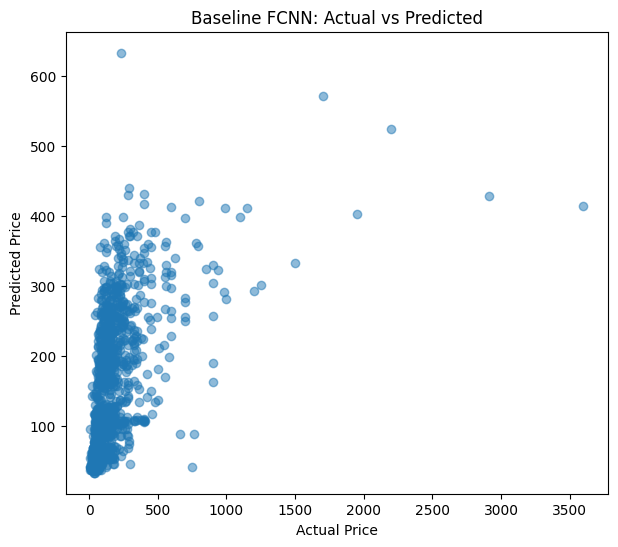

In [83]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    baseline_predictions,
    alpha=0.5
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Baseline FCNN: Actual vs Predicted")

plt.show()

In [84]:
def objective(trial):

    model = keras.Sequential([
        keras.Input(shape=(X_train_scaled.shape[1],))
    ])

    # Number of hidden layers
    n_layers = trial.suggest_int("n_layers", 1, 3)

    for i in range(n_layers):

        units = trial.suggest_int(
            f"units_{i}",
            16,
            128,
            step=16
        )

        model.add(
            layers.Dense(
                units=units,
                activation="relu"
            )
        )

        dropout = trial.suggest_float(
            f"dropout_{i}",
            0.0,
            0.5,
            step=0.1
        )

        model.add(
            layers.Dropout(dropout)
        )

    # Output layer
    model.add(layers.Dense(1))

    # Learning rate
    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-4,
        1e-2,
        log=True
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="mse",
        metrics=["mae"]
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=trial.suggest_categorical(
            "batch_size",
            [32, 64, 128]
        ),
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_mae",
                patience=5,
                restore_best_weights=True
            )
        ],
        verbose=0
    )

    return min(history.history["val_mae"])

In [85]:
study = optuna.create_study(
    direction="minimize",
    study_name="bengaluru_fcnn_optimization"
)

[I 2026-08-14 20:46:20,814] A new study created in memory with name: bengaluru_fcnn_optimization


In [87]:
study.optimize(
    objective,
    n_trials=30,
    show_progress_bar=True
)

  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-08-14 20:50:09,443] Trial 10 finished with value: 50.75775146484375 and parameters: {'n_layers': 3, 'units_0': 32, 'dropout_0': 0.0, 'units_1': 32, 'dropout_1': 0.30000000000000004, 'units_2': 16, 'dropout_2': 0.5, 'learning_rate': 0.00762541249254131, 'batch_size': 64}. Best is trial 7 with value: 41.38717269897461.
[I 2026-08-14 20:50:16,883] Trial 11 finished with value: 54.56529235839844 and parameters: {'n_layers': 1, 'units_0': 128, 'dropout_0': 0.1, 'learning_rate': 0.0009488012934819258, 'batch_size': 32}. Best is trial 7 with value: 41.38717269897461.
[I 2026-08-14 20:50:28,295] Trial 12 finished with value: 53.14249801635742 and parameters: {'n_layers': 1, 'units_0': 80, 'dropout_0': 0.5, 'learning_rate': 0.0023055322111646733, 'batch_size': 32}. Best is trial 7 with value: 41.38717269897461.
[I 2026-08-14 20:50:34,594] Trial 13 finished with value: 54.65446853637695 and parameters: {'n_layers': 1, 'units_0': 64, 'dropout_0': 0.4, 'learning_rate': 0.001239419378361807

In [88]:
print("Best Trial:", study.best_trial.number)
print("Best Validation MAE:", study.best_value)

print("\nBest Hyperparameters:")
for key, value in study.best_params.items():
    print(f"{key}: {value}")

Best Trial: 29
Best Validation MAE: 36.97406768798828

Best Hyperparameters:
n_layers: 3
units_0: 48
dropout_0: 0.0
units_1: 112
dropout_1: 0.4
units_2: 64
dropout_2: 0.4
learning_rate: 0.0005768161408448549
batch_size: 32


In [89]:
best_params = study.best_params

optimized_model = keras.Sequential()

optimized_model.add(
    keras.Input(shape=(X_train_scaled.shape[1],))
)

for i in range(best_params["n_layers"]):

    optimized_model.add(
        layers.Dense(
            best_params[f"units_{i}"],
            activation="relu"
        )
    )

    optimized_model.add(
        layers.Dropout(
            best_params[f"dropout_{i}"]
        )
    )

optimized_model.add(layers.Dense(1))

optimized_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=best_params["learning_rate"]
    ),
    loss="mse",
    metrics=["mae"]
)

optimized_model.summary()

Model: "sequential_41"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_141 (Dense)               │ (None, 48)             │           432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_99 (Dropout)            │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_142 (Dense)               │ (None, 112)            │         5,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_100 (Dropout)           │ (None, 112)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_143 (Dense)               │ (None, 64)             │         7,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_101 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_144 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,217 (51.63 KB)

 Trainable params: 13,217 (51.63 KB)

 Non-trainable params: 0 (0.00 B)

In [90]:
optimized_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_mae",
    patience=10,
    restore_best_weights=True
)

optimized_history = optimized_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=best_params["batch_size"],
    callbacks=[optimized_early_stopping],
    verbose=1
)

Epoch 1/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 27031.8477 - mae: 79.7270 - val_loss: 22294.4062 - val_mae: 57.4533
Epoch 2/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 19644.2441 - mae: 56.9992 - val_loss: 21826.7559 - val_mae: 55.8505
Epoch 3/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 20530.9219 - mae: 56.5237 - val_loss: 21900.5215 - val_mae: 52.2908
Epoch 4/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 19145.3730 - mae: 54.4723 - val_loss: 21563.5801 - val_mae: 53.5337
Epoch 5/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 18830.0742 - mae: 54.3032 - val_loss: 21345.0137 - val_mae: 54.0314
Epoch 6/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 16314.4824 - mae: 55.1283 - val_loss: 21251.3496 - val_mae: 52.4096
Epoch 7/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 16872.0938 - mae: 53.7823 - val_loss: 21035.5957 - val_mae: 52.8892
Epoch 8/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 17019.4512 - mae: 53.7987 - val_loss

In [91]:
optimized_predictions = optimized_model.predict(
    X_test_scaled,
    verbose=0
).flatten()

optimized_mae = mean_absolute_error(
    y_test,
    optimized_predictions
)

optimized_mse = mean_squared_error(
    y_test,
    optimized_predictions
)

optimized_rmse = np.sqrt(optimized_mse)

optimized_r2 = r2_score(
    y_test,
    optimized_predictions
)

print("Optimized FCNN Results")
print("----------------------")
print(f"MAE  : {optimized_mae:.4f}")
print(f"MSE  : {optimized_mse:.4f}")
print(f"RMSE : {optimized_rmse:.4f}")
print(f"R²   : {optimized_r2:.4f}")

Optimized FCNN Results
----------------------
MAE  : 36.9078
MSE  : 10287.2451
RMSE : 101.4261
R²   : 0.6059


In [92]:
results = pd.DataFrame({
    "Model": [
        "Baseline FCNN",
        "Optuna Optimized FCNN"
    ],
    "MAE": [
        baseline_mae,
        optimized_mae
    ],
    "MSE": [
        baseline_mse,
        optimized_mse
    ],
    "RMSE": [
        baseline_rmse,
        optimized_rmse
    ],
    "R2": [
        baseline_r2,
        optimized_r2
    ]
})

results

,Model,MAE,MSE,RMSE,R2
0,Baseline FCNN,50.173206,17542.148438,132.446776,0.327931
1,Optuna Optimized FCNN,36.907795,10287.245117,101.426057,0.605878


In [93]:
mae_improvement = (
    (baseline_mae - optimized_mae)
    / baseline_mae
) * 100

r2_improvement = optimized_r2 - baseline_r2

print(f"MAE Improvement: {mae_improvement:.2f}%")
print(f"R² Improvement: {r2_improvement:.4f}")

MAE Improvement: 26.44%
R² Improvement: 0.2779


80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


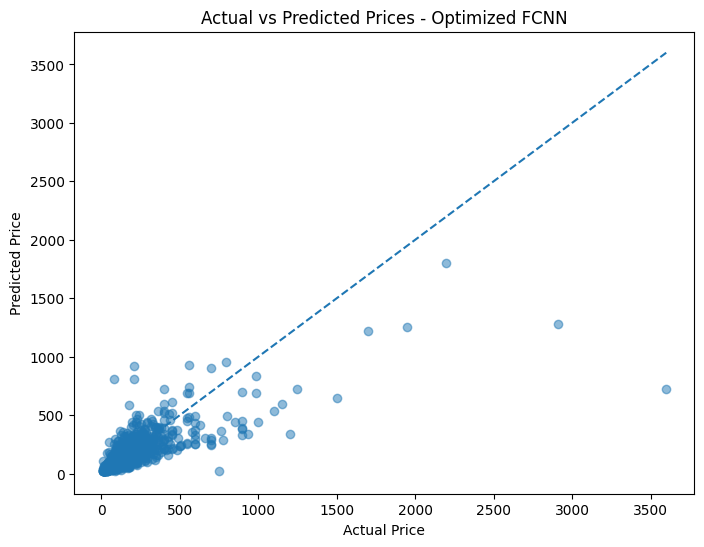

In [94]:
import matplotlib.pyplot as plt

y_pred = optimized_model.predict(X_test_scaled).flatten()

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices - Optimized FCNN")
plt.show()

In [107]:
best_params = {
    "n_layers": 3,
    "units_0": 48,
    "dropout_0": 0.0,
    "units_1": 112,
    "dropout_1": 0.4,
    "units_2": 64,
    "dropout_2": 0.4,
    "learning_rate": 0.0005768161408448549,
    "batch_size": 32
}

print("Best Hyperparameters:")
for key, value in best_params.items():
    print(f"{key}: {value}")

Best Hyperparameters:
n_layers: 3
units_0: 48
dropout_0: 0.0
units_1: 112
dropout_1: 0.4
units_2: 64
dropout_2: 0.4
learning_rate: 0.0005768161408448549
batch_size: 32
